# Security filters · 2. Scenarios

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ula-uab/lscm-decision-making/blob/main/cases/security_filters/notebooks/02_scenarios.ipynb)

With the presentation curve of a day, how many filters do we need, and when? A **scenario** fixes the assumptions (load factor, arrival profile and capacity of the filters in each slot). Running several scenarios on the same day shows how the queue and the idle time of the filters change.

In [1]:
# In Google Colab, install the package from GitHub (it takes a few seconds).
# On your own computer, install the repository environment instead (see README).
import sys
if "google.colab" in sys.modules:
    %pip install -q "git+https://github.com/ula-uab/lscm-decision-making#subdirectory=cases/security_filters"

In [2]:
import security_filters as sf
from security_filters.plots import plot_scenario

schedule = sf.read_schedule()
profiles = sf.read_profiles()
day = "2008-07-19"
flights = sf.flights_for_curve(schedule, day)

## 1. How the queue is computed

In each 5-minute slot the filters can serve up to `capacity` passengers. Those who cannot be served wait for the next slot:

- served = min(capacity, queue of the previous slot + arrivals)
- queue = queue of the previous slot + arrivals − served
- idle = (capacity − served) / capacity

Capacity is given in passengers per 5 minutes. The helpers build it in three ways:

- `sf.capacity_by_hour({6: 400, 7: 500}, default=100)`: one value per hour;
- `sf.capacity_from_lanes(open_lanes, passengers_per_lane_per_hour)`: from the number of open lanes;
- `sf.capacity_from_fraction(fraction, max_capacity=500)`: as a fraction of the maximum, as in the original workbook.

## 2. Define the scenarios

In [3]:
# Passengers start arriving around 02:30, so the filters open at 02:00.
# Capacity in passengers per 5 minutes; 50 while the airport is almost closed.
open_hours = {h: 400 for h in range(2, 24)}
flat = sf.Scenario("flat 400", capacity=sf.capacity_by_hour(open_hours, default=50))

# 500 in the morning and evening peaks
peaks = open_hours | {h: 500 for h in range(7, 12)} | {h: 500 for h in range(16, 19)}
reinforced = sf.Scenario("peaks reinforced", capacity=sf.capacity_by_hour(peaks, default=50))

# Same capacity, but only 85 % of the seats occupied
fuller = sf.Scenario("peaks reinforced, 85 % load", capacity=sf.capacity_by_hour(peaks, default=50),
                     load_factor=0.85)

scenarios = [flat, reinforced, fuller]

## 3. Compare them

In [4]:
sf.compare(scenarios, flights, profiles).round(2)

,flat 400,peaks reinforced,"peaks reinforced, 85 % load"
passengers,77265.553834,77265.553834,65675.720759
max_queue,1348.396287,27.033476,0.0
time_of_max_queue,11:35,06:55,-
slots_with_queue,104,2,0
queue_at_midnight,0.0,0.0,0.0
average_wait_min,4.507519,0.002184,0.0
capacity_used,0.72346,0.663793,0.564224
average_idle,0.304621,0.37367,0.467579


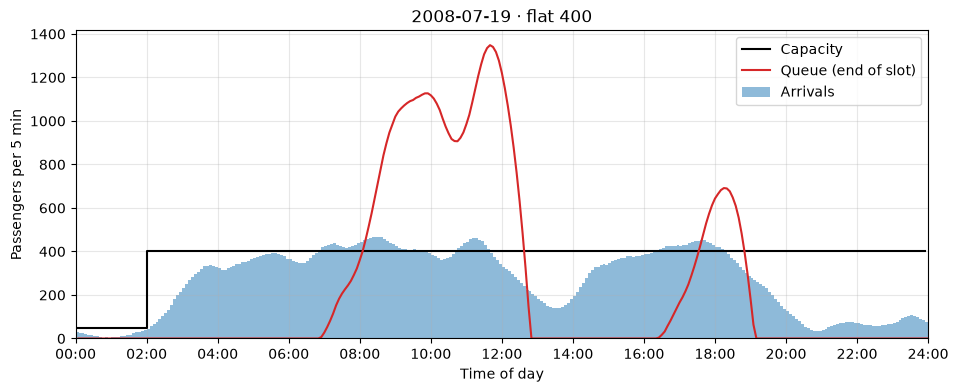

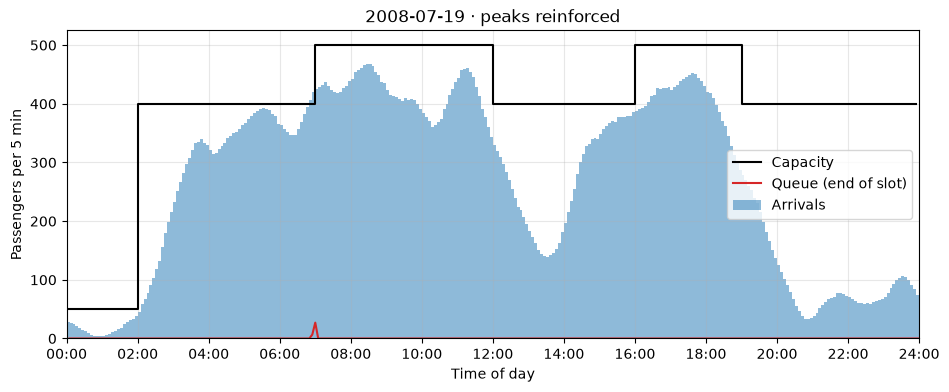

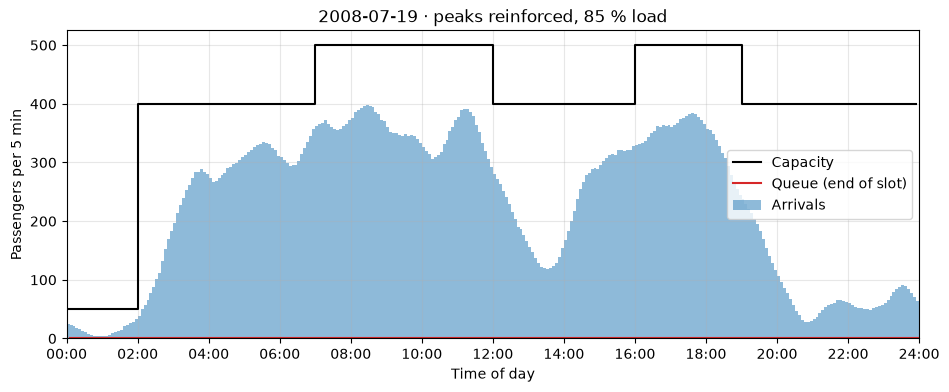

In [5]:
for scenario in scenarios:
    plot_scenario(sf.run(scenario, flights, profiles), title=f"{day} · {scenario.name}")

## 4. Try it yourself

- Find the smallest capacity per hour that keeps the maximum queue below 100 passengers.
- What happens with the `"gauss"` profile, where passengers arrive closer to departure?
- Compare two days with the same scenario.